# Study 8 -- Results: Joint lam x xi_step_scale sweep

Loads cached results from `outputs/study8_full/` (1800 runs: 9 conditions x
100 images x 2 models, 2000 queries each).

Study 7 found that the Study 3/5/6 tunings (validated at `lam_override=14`)
do not transfer to `lam_override=None` (=28): `xi_step_scale=0.5` stopped
being a clear win once `lam=28`. This study sweeps both knobs jointly:

```
LAM_VALUES = [14, 28, 42]
XI_VALUES  = [0.5, 0.75, 1.0]
carrier (held fixed): tau=3, bs_adaptive=True, bs_cap=26, cmu_scale=1.0
```

9 conditions named `L{lam}_X{int(xi*100):03d}`, e.g. `L14_X050`. Note
`L28_X050` is *exactly* Study 7's `tuned` condition / EC1's `sep` condition
(same config, paired same seeds) -- a useful internal consistency check and
a natural reference point for paired comparisons.

**Caveat up front**: this grid uses `tau=3` (the carrier value), *not*
Study 6's `tau=0`. Study 6's best validated configuration
(`lam=14, xi_step_scale=0.5, tau=0` -> IR=0.441/0.071) is therefore not
reproduced anywhere in this grid -- `L14_X050` here (`tau=3`) gets
IR=0.338/0.050, well below it. This study answers "given `tau=3`, how do
`lam` and `xi_step_scale` interact?", not "what's the best setting overall
across all four knobs at once".

**Question.** Is `xi_step_scale=0.5` still optimal once `lam` is varied, or
does the optimal `xi_step_scale` shift with `lam`?


In [1]:
import pandas as pd, numpy as np, pickle
from IPython.display import Image, display

OUT = 'outputs/study8_full'
df = pd.read_parquet(f'{OUT}/results.parquet')
with open(f'{OUT}/trajectories.pkl', 'rb') as f:
    all_traj = pickle.load(f)

ok = df[df.success]
print(f'{len(df)} runs total, {len(ok)} successful ({df.success.mean()*100:.1f}%)')
ok.head()


1800 runs total, 1710 successful (95.0%)


,condition,model,image_idx,lam,xi_step_scale,true_class,success,queries,init_l2,best_l2,...,backtracks_total,bs_calls,bs_queries_actual,l2_at_250,l2_at_500,l2_at_750,l2_at_1000,l2_at_1500,l2_at_2000,improvement_ratio
0,L14_X050,standard,0,14,0.5,3,True,2024,3.052553,3.052553,...,3,6,148,3.058724,3.058724,3.058724,3.058724,3.058724,3.058724,0.000000
1,L14_X050,standard,1,14,0.5,8,True,2025,4.176711,1.257285,...,2,45,1170,2.636295,2.117488,1.964799,1.777939,1.453505,1.257287,0.698977
2,L14_X050,standard,2,14,0.5,8,True,2026,2.302839,1.639359,...,3,21,544,1.904092,1.660662,1.639506,1.639359,1.639359,1.639359,0.288114
3,L14_X050,standard,3,14,0.5,0,True,2005,0.973804,0.573346,...,13,54,1204,0.758712,0.721345,0.677320,0.674250,0.625140,0.573352,0.411231
4,L14_X050,standard,4,14,0.5,6,True,2004,12.981510,6.051147,...,2,44,1144,11.588572,11.570182,10.712518,7.800680,6.671388,6.051147,0.533864


## Summary table

In [2]:
LAM_VALUES = [14, 28, 42]
XI_VALUES  = [0.5, 0.75, 1.0]
COND_ORDER  = [f'L{lam}_X{int(xi*100):03d}' for lam in LAM_VALUES for xi in XI_VALUES]
MODEL_NAMES = ['standard', 'robust']

summary = ok.groupby(['condition','model']).agg(
    n               = ('best_l2', 'count'),
    median_init     = ('init_l2', 'median'),
    median_best     = ('best_l2', 'median'),
    median_final    = ('final_l2', 'median'),
    median_IR       = ('improvement_ratio', 'median'),
    median_gen      = ('n_generations', 'median'),
    median_queries  = ('queries', 'median'),
    median_bsq      = ('bs_queries_actual', 'median'),
).round(4)
summary = summary.reindex(
    pd.MultiIndex.from_product([COND_ORDER, MODEL_NAMES], names=['condition','model'])
)
summary


n  median_init  median_best  median_final  median_IR  \
condition model                                                              
L14_X050  standard  100       3.9905       2.6883        2.6887     0.3381   
          robust     90       7.5018       6.9151        6.9151     0.0504   
L14_X075  standard  100       3.9905       2.6411        2.6419     0.3129   
          robust     90       7.5018       6.7806        6.7820     0.0706   
L14_X100  standard  100       3.9905       2.5237        2.5251     0.3172   
          robust     90       7.5018       6.9300        6.9547     0.0594   
L28_X050  standard  100       3.9905       2.7016        2.7016     0.3194   
          robust     90       7.5018       6.9084        6.9084     0.0444   
L28_X075  standard  100       3.9905       2.6018        2.6050     0.3316   
          robust     90       7.5018       6.9231        6.9234     0.0496   
L28_X100  standard  100       3.9905       2.5906        2.5906     0.3130   
          robust     90       7.5018       6.8548        6.8627     0.0545   
L42_X050  standard  100       3.9905       2.6819        2.6822     0.3014   
          robust     90       7.5018       6.8991        6.8991     0.0498   
L42_X075  standard  100       3.9905       2.4153        2.4186     0.3601   
          robust     90       7.5018       6.9366        6.9383     0.0582   
L42_X100  standard  100       3.9905       2.7208        2.7253     0.3506   
          robust     90       7.5018       6.8706        6.8859     0.0502   

                    median_gen  median_queries  median_bsq  
condition model                                             
L14_X050  standard        38.0          2024.0      1158.5  
          robust          12.0          2026.0       623.5  
L14_X075  standard        19.0          2025.5       711.0  
          robust          16.0          2026.0      1026.5  
L14_X100  standard        15.5          2025.0       765.5  
          robust          17.5          2026.0      1202.0  
L28_X050  standard        30.0          2024.5       910.0  
          robust          10.0          2026.0       594.5  
L28_X075  standard        25.0          2025.0       882.0  
          robust          13.0          2026.0       882.5  
L28_X100  standard        12.0          2026.0       611.0  
          robust          15.0          2026.0      1000.5  
L42_X050  standard        25.0          2025.0       741.5  
          robust          10.0          2026.0       584.0  
L42_X075  standard        24.0          2025.0       754.0  
          robust          12.5          2026.0       776.0  
L42_X100  standard        21.0          2026.0       769.0  
          robust          14.0          2026.0       897.0

## Headline result: the optimal `xi_step_scale` depends on `lam`

| condition | lam | xi | standard IR | standard gen | robust IR | robust gen |
|---|---|---|---|---|---|---|
| L14_X050 | 14 | 0.50 | 0.3381 | 38.0 | 0.0504 | 12.0 |
| L14_X075 | 14 | 0.75 | 0.3129 | 19.0 | **0.0706** | 16.0 |
| L14_X100 | 14 | 1.00 | 0.3172 | 15.5 | 0.0594 | 17.5 |
| L28_X050 | 28 | 0.50 | 0.3194 | 30.0 | 0.0444 | 10.0 |
| L28_X075 | 28 | 0.75 | 0.3316 | 25.0 | 0.0496 | 13.0 |
| L28_X100 | 28 | 1.00 | 0.3130 | 12.0 | 0.0545 | 15.0 |
| L42_X050 | 42 | 0.50 | 0.3014 | 25.0 | 0.0498 | 10.0 |
| L42_X075 | 42 | 0.75 | **0.3601** | 24.0 | 0.0582 | 12.5 |
| L42_X100 | 42 | 1.00 | 0.3506 | 21.0 | 0.0502 | 14.0 |

**Standard model**: `xi_step_scale=0.5` is only the best choice at `lam=14`
(0.3381 vs 0.3129/0.3172). At `lam=28` and `lam=42`, `xi_step_scale=0.75`
wins instead -- and at `lam=42`, `L42_X075` (IR=0.3601) is the best *single*
cell in the entire grid.

**Robust model**: `lam=14, xi_step_scale=0.75` (IR=0.0706) is a clear
standout -- it's the only cell in the grid that comes close to Study 6's
`tau=0` result (0.071), despite using `tau=3` here. `lam=28` is uniformly
the worst row for robust (0.044-0.055) regardless of `xi_step_scale`.

So `xi_step_scale=0.5` (Study 3's pick, validated at `lam=14`) is *not* a
globally optimal choice once `lam` varies -- the optimum shifts to
`xi_step_scale=0.75` for both larger `lam` (standard) and for `lam=14`
itself on the robust model.


## A: Median improvement ratio, lam x xi_step_scale (heatmap)

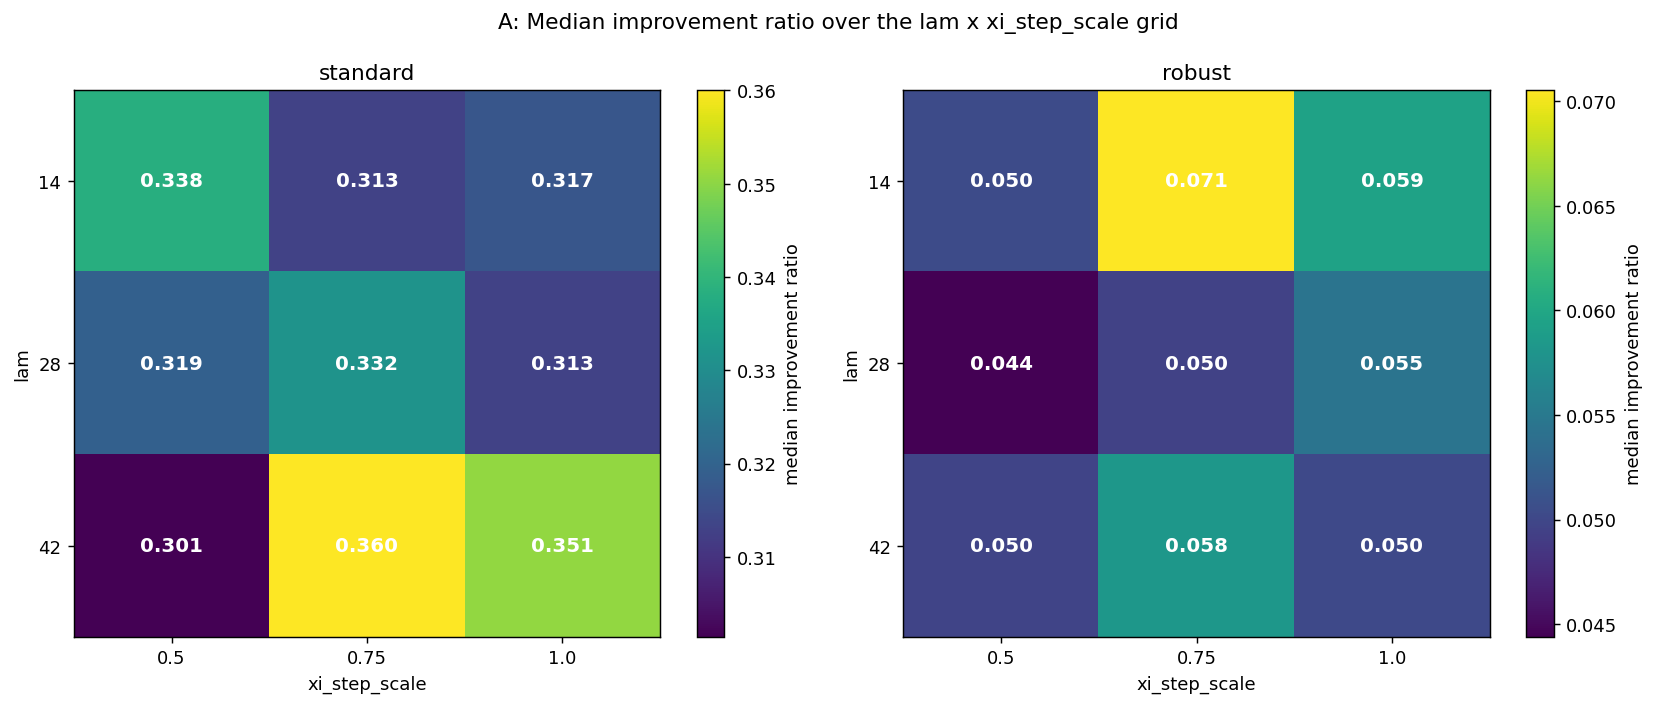

In [3]:
display(Image(f'{OUT}/A_ir_heatmap.png'))

## B: IR vs xi_step_scale, one line per lam

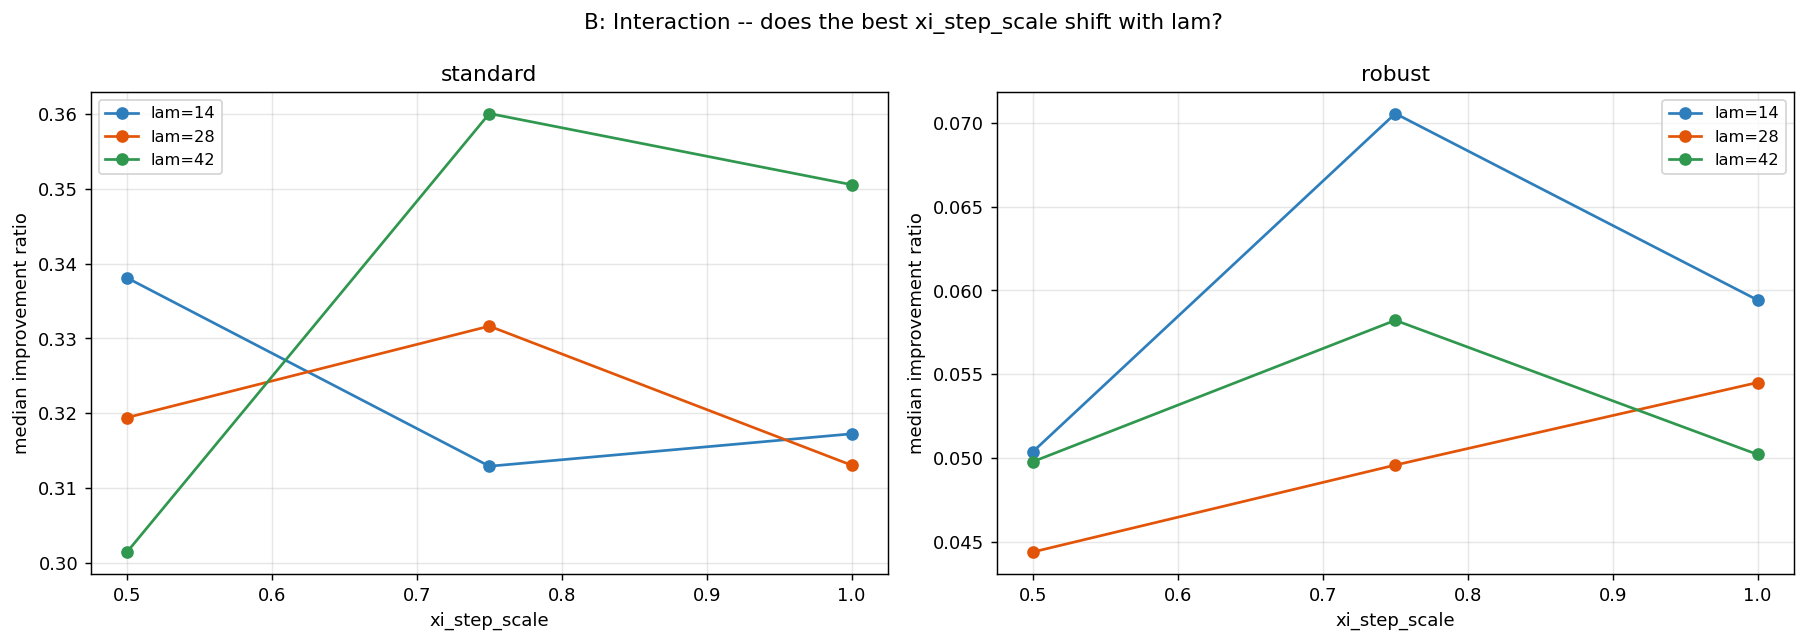

In [4]:
display(Image(f'{OUT}/B_interaction.png'))

The interaction is visible directly: on the **standard** model the
`lam=14` line peaks at `xi=0.5` and falls off, while the `lam=28` and
`lam=42` lines both peak at `xi=0.75`. On the **robust** model, `lam=14`
has a sharp peak at `xi=0.75`; `lam=28` stays low and roughly flat across
all three `xi` values, and `lam=42` also peaks (more mildly) at `xi=0.75`.


## C: Final best_l2 distributions

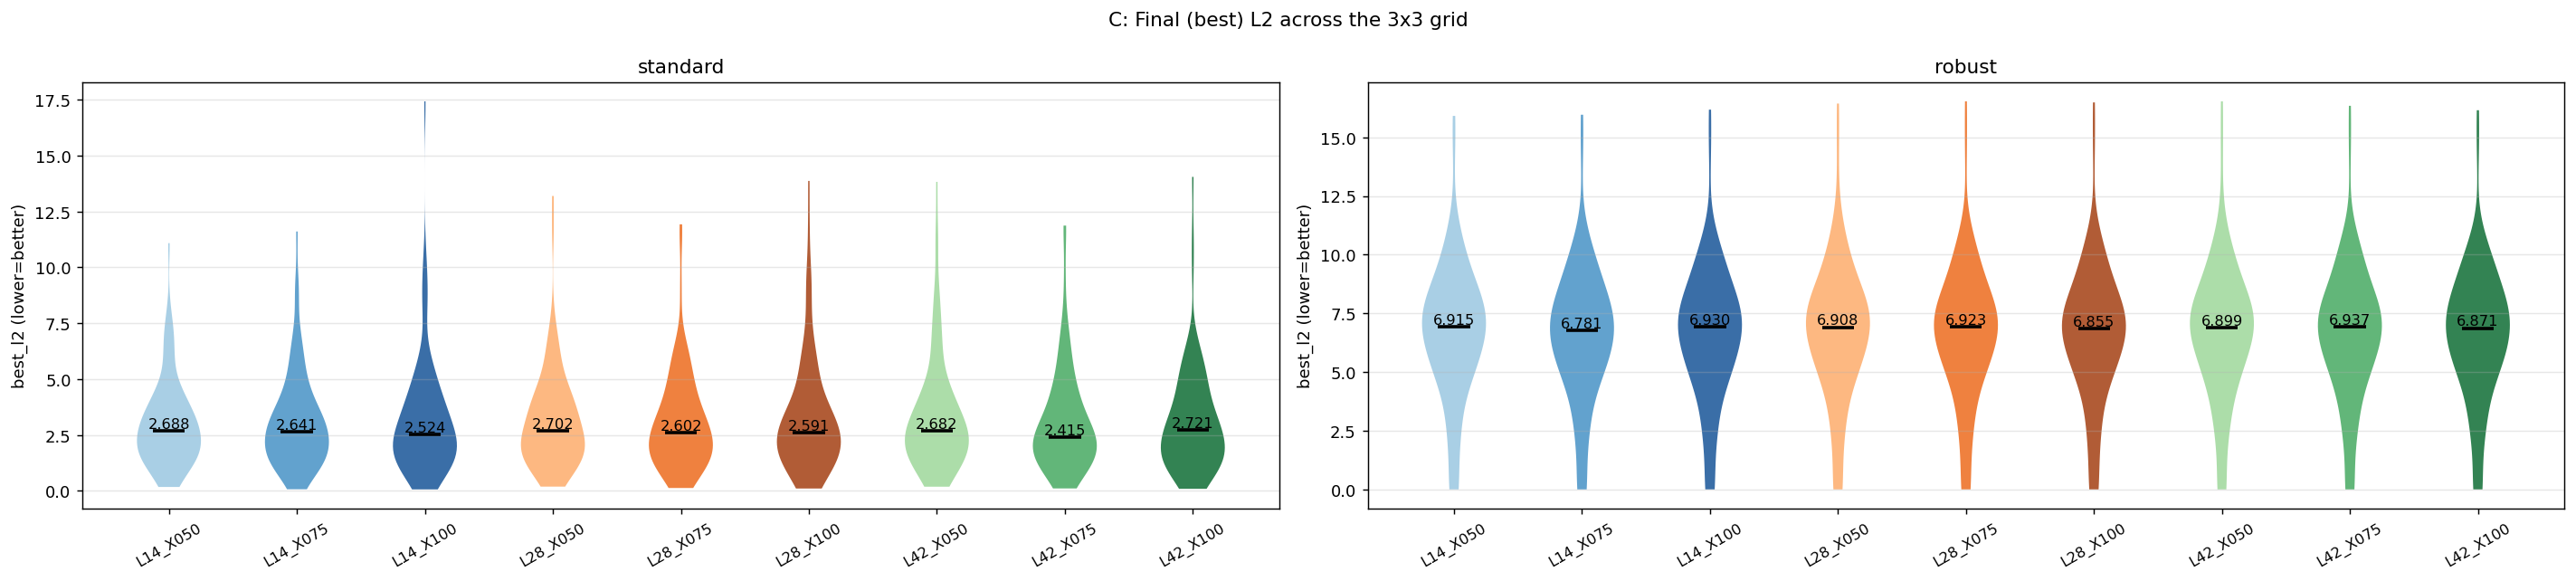

In [5]:
display(Image(f'{OUT}/C_final_l2.png'))

## D: Median generations, lam x xi_step_scale (sanity check)

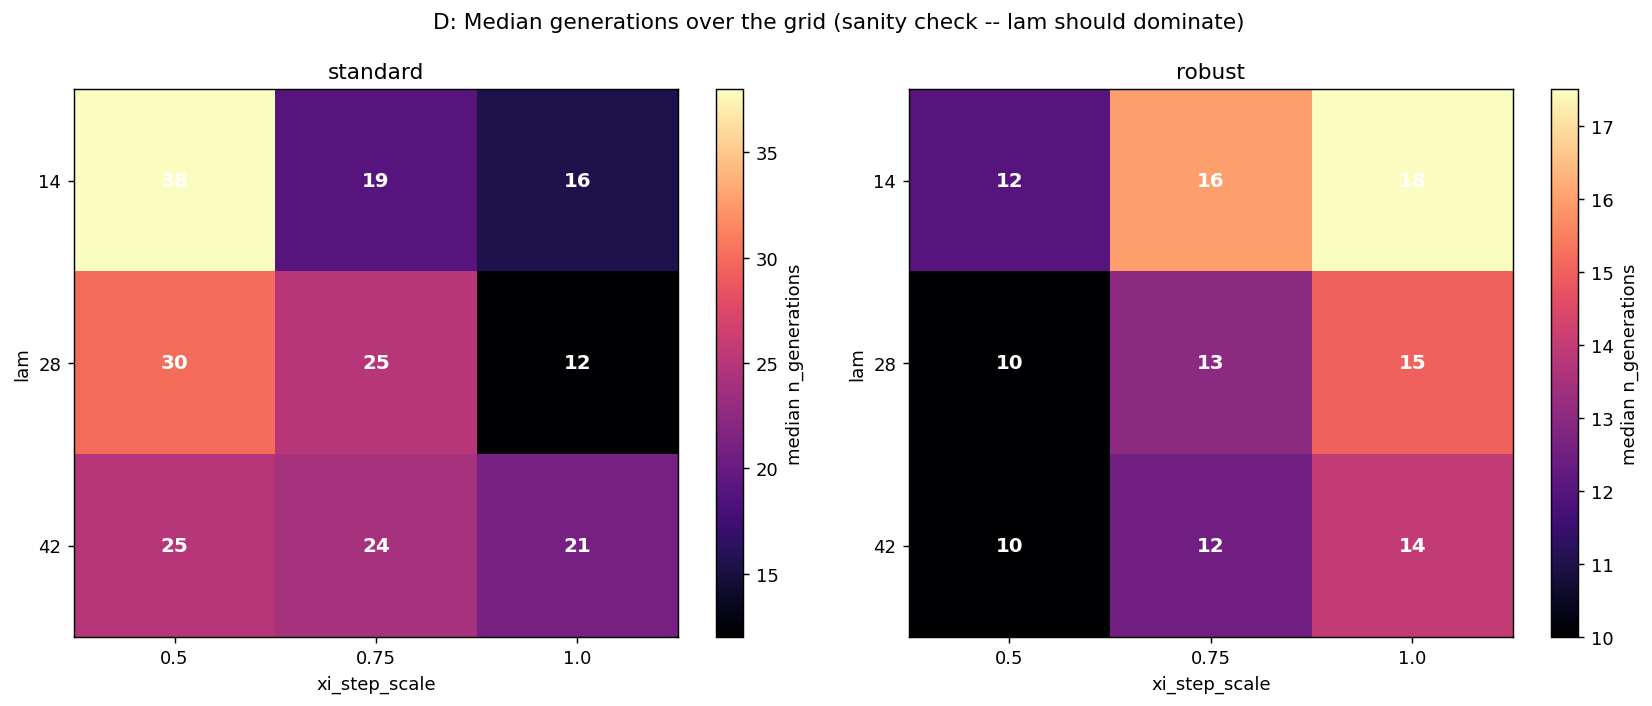

In [6]:
display(Image(f'{OUT}/D_generations_heatmap.png'))

As expected, larger `lam` generally means fewer generations (more
offspring evaluated per generation consumes the query budget faster) --
clearly true for the **robust** model (each `xi` column decreases
monotonically: e.g. `xi=0.50`: 12 -> 10 -> 10; `xi=1.00`: 17.5 -> 15 -> 14).

For the **standard** model the `lam=14` column is the odd one out: at
`xi=0.50` it has *far more* generations (38) than `lam=28`/`lam=42` at the
same `xi` (30/25) -- the opposite of the robust trend. Across `xi` at fixed
`lam`, the standard-model generation counts are also non-monotonic for
`lam=28` (30 -> 25 -> 12, decreasing) and `lam=42` (25 -> 24 -> 21,
decreasing) but `lam=14` drops sharply then levels off (38 -> 19 -> 15.5).
This is most likely driven by `bs_queries_actual` (adaptive binary search
efficiency varies with the step-size/lam combination, changing how many
queries each generation actually consumes) rather than a simple
`max_queries / (lam + overhead)` formula -- a secondary effect, not the
main finding of this study.


## Paired per-image comparison vs L28_X050 (= Study 7 `tuned` = EC1 `sep`)

In [7]:
print('=== PAIRED COMPARISON (per image, best_l2 vs L28_X050) ===')
base = {m: ok[(ok.condition=='L28_X050')&(ok.model==m)].set_index('image_idx')['best_l2']
        for m in MODEL_NAMES}
for cname in COND_ORDER:
    if cname == 'L28_X050':
        continue
    for mname in MODEL_NAMES:
        oth = ok[(ok.condition==cname)&(ok.model==mname)].set_index('image_idx')['best_l2']
        common = base[mname].index.intersection(oth.index)
        b, o_ = base[mname].loc[common], oth.loc[common]
        win_rate = float((o_ < b).mean())
        rel_impr = float(np.median((b - o_) / b))
        print(f'{cname:9s} vs L28_X050 | {mname:8s}: n={len(common)}  '
              f'{cname}-wins={win_rate*100:5.1f}%  median rel impr={rel_impr*100:+.2f}%')


=== PAIRED COMPARISON (per image, best_l2 vs L28_X050) ===
L14_X050  vs L28_X050 | standard: n=100  L14_X050-wins= 64.0%  median rel impr=+4.26%
L14_X050  vs L28_X050 | robust  : n=90  L14_X050-wins= 58.9%  median rel impr=+0.27%
L14_X075  vs L28_X050 | standard: n=100  L14_X075-wins= 53.0%  median rel impr=+1.34%
L14_X075  vs L28_X050 | robust  : n=90  L14_X075-wins= 68.9%  median rel impr=+1.14%
L14_X100  vs L28_X050 | standard: n=100  L14_X100-wins= 61.0%  median rel impr=+5.47%
L14_X100  vs L28_X050 | robust  : n=90  L14_X100-wins= 70.0%  median rel impr=+1.23%
L28_X075  vs L28_X050 | standard: n=100  L28_X075-wins= 61.0%  median rel impr=+5.03%
L28_X075  vs L28_X050 | robust  : n=90  L28_X075-wins= 67.8%  median rel impr=+0.69%
L28_X100  vs L28_X050 | standard: n=100  L28_X100-wins= 50.0%  median rel impr=+0.01%
L28_X100  vs L28_X050 | robust  : n=90  L28_X100-wins= 56.7%  median rel impr=+0.52%
L42_X050  vs L28_X050 | standard: n=100  L42_X050-wins= 44.0%  median rel impr=-2.32%


Eight of the nine conditions beat (or roughly tie) `L28_X050` by both
win-rate and median relative improvement on at least one model:

- **L14_X050, L14_X075, L14_X100** (all `lam=14`): all clearly better than
  `L28_X050` on both models -- win rates 53-70%, median relative
  improvements +1.3% to +5.5%. `lam=14` is a robust improvement over
  `lam=28` regardless of `xi_step_scale`, even though none of these match
  Study 6's `tau=0` numbers (see caveat above).
- **L28_X075**: better than `L28_X050` on both models (61.0% / 67.8% win
  rate, +5.0% / +0.7%) -- confirms `xi_step_scale=0.75` is better than
  `0.5` once `lam` is fixed at 28.
- **L28_X100**: a wash on standard (50.0% win rate, +0.01%), modestly
  better on robust (56.7%, +0.5%).
- **L42_X075, L42_X100**: both better than `L28_X050` on both models
  (55-63% win rate, +0.6% to +4.9%).
- **L42_X050**: the one condition that's *worse* than `L28_X050` --
  44.0%/48.9% win rate, -2.3%/-0.0% median. `xi_step_scale=0.5` is a poor
  match for `lam=42`.

So `L28_X050` (the Study 7 / EC1 carrier config) is close to the *worst*
point in this 3x3 grid -- almost any other combination tried here is at
least as good, and several (`lam=14` at any `xi`, or `lam>=28` paired with
`xi_step_scale=0.75`) are clearly better.


## Conclusions

1. **`xi_step_scale=0.5` is not a globally optimal choice.** It was
   validated at `lam=14` (Study 3) and remains the best `xi` for `lam=14`
   on the *standard* model, but for `lam=28`/`lam=42` (standard) and even
   for `lam=14` itself (robust), `xi_step_scale=0.75` is better.
2. **`lam=14` beats `lam=28` (the prior default) at every `xi_step_scale`
   tried here**, on both models -- consistent with Study 7's finding that
   `lam=28` wastes the benefit of smaller steps, but now showing the
   reverse also holds: smaller `lam` helps regardless of step size.
3. **Best single cell, standard model**: `L42_X075` (IR=0.3601, `lam=42,
   xi=0.75`). **Best single cell, robust model**: `L14_X075` (IR=0.0706,
   `lam=14, xi=0.75`) -- the only result in this grid that approaches
   Study 6's `tau=0` robust IR (0.071), despite this grid's `tau=3`.
4. **No single `(lam, xi)` pair dominates both models simultaneously**:
   `L14_X075` is excellent for robust (0.0706) but mid-table for standard
   (0.3129); `L42_X075` is the best for standard (0.3601) but only
   middling for robust (0.0582). `L14_X050` (Study 3's original pick) is
   the best balance among cells that do reasonably on *both* (0.3381 /
   0.0504), though still well below Study 6's `tau=0`+`lam=14`+`xi=0.5`
   combination.

## Next step

This grid fixes `tau=3`. The natural follow-up is revisiting `tau` (0 vs 3)
at the `(lam, xi)` combinations that did best here -- particularly
`L14_X075` and `L42_X075` -- to see whether `tau=0`'s anytime-availability
benefit (Study 6) combines with these `(lam, xi)` choices as cleanly as it
did with `lam=14, xi=0.5`. Deferred to a future study.
